# Santander Customer Satisfaction — Imbalanced, High-Dimensional Classification

Real Kaggle competition data (see `data/santander/SOURCE.md`): a **stratified
15,000-row subsample** of the 76,020-row training set, preserving the true
**3.96% positive rate** exactly (594 satisfied=0/unsatisfied=1 target, seed=42).
371 anonymized numeric columns (`ID` + `TARGET` + 369 features) — a classic
"wide, sparse-signal, imbalanced" tabular problem.

This notebook demonstrates:
- Full EDA on a **wide** frame (369 numeric features) — including how
  `EDAAnalyzer` protects itself against O(n^2) blowups by capping the
  correlation matrix at 20 columns (disclosed, not hidden).
- **Drift detection** (`DriftCalculator`) comparing the train split vs. the
  test split, standing in for a train-vs-production check.
- A leakage-safe **wide-frame pipeline**: `VarianceThreshold` (drop the many
  constant columns — a well-known quirk of this dataset) -> `CorrelationThreshold`
  (collapse near-duplicate features) -> `StandardScaler` -> `Oversampling`
  (SMOTE, fit on the *training* split only) -> model.
- Model comparison focused on **ROC-AUC** (the real competition metric) and
  precision/recall, not accuracy (which is misleading at ~96/4 imbalance).

Polars + numpy only — no pandas.

In [1]:
import numpy as np
import polars as pl

from skyulf import SkyulfPipeline
from skyulf.profiling.analyzer import EDAAnalyzer
from skyulf.profiling.visualizer import EDAVisualizer
from skyulf.profiling.drift import DriftCalculator

train = pl.read_csv("data/santander/train_sample.csv", infer_schema_length=None)
print(train.shape)
print(f"TARGET positive rate: {train['TARGET'].mean():.4%}")
train.head(3)

(15000, 371)
TARGET positive rate: 3.9600%


ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,imp_op_var41_comer_ult1,imp_op_var41_comer_ult3,imp_op_var41_efect_ult1,imp_op_var41_efect_ult3,imp_op_var41_ult1,imp_op_var39_efect_ult1,imp_op_var39_efect_ult3,imp_op_var39_ult1,imp_sal_var16_ult1,ind_var1_0,ind_var1,ind_var2_0,ind_var2,ind_var5_0,ind_var5,ind_var6_0,ind_var6,ind_var8_0,ind_var8,ind_var12_0,ind_var12,ind_var13_0,ind_var13_corto_0,ind_var13_corto,ind_var13_largo_0,ind_var13_largo,…,saldo_medio_var8_hace3,saldo_medio_var8_ult1,saldo_medio_var8_ult3,saldo_medio_var12_hace2,saldo_medio_var12_hace3,saldo_medio_var12_ult1,saldo_medio_var12_ult3,saldo_medio_var13_corto_hace2,saldo_medio_var13_corto_hace3,saldo_medio_var13_corto_ult1,saldo_medio_var13_corto_ult3,saldo_medio_var13_largo_hace2,saldo_medio_var13_largo_hace3,saldo_medio_var13_largo_ult1,saldo_medio_var13_largo_ult3,saldo_medio_var13_medio_hace2,saldo_medio_var13_medio_hace3,saldo_medio_var13_medio_ult1,saldo_medio_var13_medio_ult3,saldo_medio_var17_hace2,saldo_medio_var17_hace3,saldo_medio_var17_ult1,saldo_medio_var17_ult3,saldo_medio_var29_hace2,saldo_medio_var29_hace3,saldo_medio_var29_ult1,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
92160,2,27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0
150675,2,24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57168.45,0
131557,2,39,0.0,400.17,400.17,0.0,0.0,0.0,0.0,0.0,400.17,400.17,0.0,0.0,400.17,0.0,0.0,400.17,0.0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63967.65,0


## 1. Full EDA

369 numeric feature columns is far more than any correlation heatmap can show
usefully, and `EDAAnalyzer` protects itself with a hard 20-column cap on the
correlation matrix (the warning below is expected and by design, not a bug).

In [2]:
profile = EDAAnalyzer(train.drop("ID")).analyze(target_col="TARGET")

print(f"Rows: {profile.row_count}  Columns: {len(profile.columns)}")
print(f"Missing cells: {profile.missing_cells_percentage:.2f}%")
print(f"Alerts ({len(profile.alerts)} total), first 8:")
for a in profile.alerts[:8]:
    print(" -", a.message)

calculate_correlations: 369 numeric columns exceeds the 20-column cap; truncating to the first 20 by column order (not variance or relevance) and dropping ['ind_var1', 'ind_var2_0', 'ind_var2', 'ind_var5_0', 'ind_var5', 'ind_var6_0', 'ind_var6', 'ind_var8_0', 'ind_var8', 'ind_var12_0', 'ind_var12', 'ind_var13_0', 'ind_var13_corto_0', 'ind_var13_corto', 'ind_var13_largo_0', 'ind_var13_largo', 'ind_var13_medio_0', 'ind_var13_medio', 'ind_var13', 'ind_var14_0', 'ind_var14', 'ind_var17_0', 'ind_var17', 'ind_var18_0', 'ind_var18', 'ind_var19', 'ind_var20_0', 'ind_var20', 'ind_var24_0', 'ind_var24', 'ind_var25_cte', 'ind_var26_0', 'ind_var26_cte', 'ind_var26', 'ind_var25_0', 'ind_var25', 'ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var29_0', 'ind_var29', 'ind_var30_0', 'ind_var30', 'ind_var31_0', 'ind_var31', 'ind_var32_cte', 'ind_var32_0', 'ind_var32', 'ind_var33_0', 'ind_var33', 'ind_var34_0', 'ind_var34', 'ind_var37_cte', 'ind_var37_0', 'ind_var37', 'ind_var39_0', 'ind_var

/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
calculate_correlations: 370 numeric columns exceeds the 20-column cap; truncating to the first 20 by column order (not variance or relevance) and dropping ['ind_var1', 'ind_var2_0', 'ind_var2', 'ind_var5_0', 'ind_var5', 'ind_var6_0', 'ind_var6', 'ind_var8_0', 'ind_var8', 'ind_var12_0', 'ind_var12', 'ind_var13_0', 'ind_var13_corto_0', 'ind_var13_corto', 'ind_var13_largo_0', 'ind_var13_largo', 'ind_var13_medio_0', 'ind_var13_medio', 'ind_var13', 'ind_var14_0', 'ind_var14', 'ind_var17_0', 'ind_var17', 'ind_var18_0', 'ind_var18', 'ind_var19', 'ind_var20_0', 'ind_var20', 'ind_var24_0', 'ind_var24', 'ind_var25_cte', 'ind_var26_0', 'ind_var26_cte', 'ind_var26

/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Rows: 15000  Columns: 370
Missing cells: 0.00%
Alerts (29 total), first 8:
 - Column 'var15' contains significant outliers.
 - Column 'saldo_var5' contains significant outliers.
 - Column 'saldo_var6' is constant.
 - Column 'saldo_var29' is constant.
 - Column 'saldo_var30' contains significant outliers.
 - Column 'saldo_var42' contains significant outliers.
 - Column 'imp_amort_var18_ult1' is constant.
 - Column 'imp_amort_var34_ult1' is constant.


In [3]:
constant_alerts = [a.message for a in profile.alerts if "constant" in a.message.lower()]
print(f"{len(constant_alerts)} columns flagged constant by EDA (well-known quirk of this dataset).")

outlier_alerts = [a.message for a in profile.alerts if "outlier" in a.message.lower()]
print(f"{len(outlier_alerts)} columns flagged with significant outliers.")

14 columns flagged constant by EDA (well-known quirk of this dataset).
15 columns flagged with significant outliers.


In [4]:
print("Top recommendations from the profile:")
for r in profile.recommendations[:6]:
    print(" -", r.message if hasattr(r, "message") else r)

Top recommendations from the profile:
 - column='var3' action='Transform' reason='High skewness (-26.67)' suggestion="Apply Log or Box-Cox transformation to 'var3'."
 - column='var15' action='Transform' reason='High skewness (1.56)' suggestion="Apply Log or Box-Cox transformation to 'var15'."
 - column='imp_ent_var16_ult1' action='Transform' reason='High skewness (39.53)' suggestion="Apply Log or Box-Cox transformation to 'imp_ent_var16_ult1'."
 - column='imp_op_var39_comer_ult1' action='Transform' reason='High skewness (9.55)' suggestion="Apply Log or Box-Cox transformation to 'imp_op_var39_comer_ult1'."
 - column='imp_op_var39_comer_ult3' action='Transform' reason='High skewness (11.08)' suggestion="Apply Log or Box-Cox transformation to 'imp_op_var39_comer_ult3'."
 - column='imp_op_var40_comer_ult1' action='Transform' reason='High skewness (45.53)' suggestion="Apply Log or Box-Cox transformation to 'imp_op_var40_comer_ult1'."


In [5]:
EDAVisualizer(profile, train.drop("ID")).summary()

╭────────────────────╮
│ Skyulf EDA Summary │
╰────────────────────╯

1. Data Quality

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Metric         ┃ Value          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Rows           │ 15000          │
│ Columns        │ 370            │
│ Missing Cells  │ 0.0%           │
│ Duplicate Rows │ 817            │
│ Target Column  │ TARGET         │
│ Task Type      │ Classification │
└────────────────┴────────────────┘

2. Numeric Statistics

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Column                ┃        Mean ┃          Std ┃        Min ┃           Max ┃   Skew ┃     Kurt ┃ Normality ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━┩
│ var3                  │    -1397.32 │     37391.68 │ -999999.00 │        238.00 │ -26.67 │   709.29 │    No     │
│ var15                 │       33.19 │        12.85 │       5.00 │        102.00 │   1.56 │     2.47 │    No     │
│ imp_ent_var16_ult1    │       74.49 │      1000.31 │       0.00 │      72000.00 │  39.53 │  2256.07 │    No     │
│ imp_op_var39_comer_u… │       75.47 │       361.70 │       0.00 │       8675.70 │   9.55 │   132.93 │    No     │
│ imp_op_var39_comer_u… │      124.03 │       584.57 │       0.00 │      21024.81 │  11.08 │   215.46 │    No     │
│ imp_op_var40_comer_u… │        4.16 │       114.92 │       0.00 │       7904.22 │  45.53 │  2502.49 │    No     │
│ imp_op_var40_comer_u… │        7.56 │       173.90 │       0.00 │       9133.98 │  33.88 │  1344.09 │    No     │
│ imp_op_var40_efect_u… │        0.17 │        10.99 │       0.00 │        930.00 │  72.58 │  5457.86 │    No     │
│ imp_op_var40_efect_u… │        0.39 │        21.95 │       0.00 │       1650.00 │  64.75 │  4477.29 │    No     │
│ imp_op_var40_ult1     │        3.15 │        91.56 │       0.00 │       7904.22 │  58.04 │  4338.47 │    No     │
│ imp_op_var41_comer_u… │       71.31 │       336.98 │       0.00 │       8675.70 │   9.38 │   133.59 │    No     │
│ imp_op_var41_comer_u… │      116.47 │       537.19 │       0.00 │      16566.81 │  10.36 │   180.85 │    No     │
│ imp_op_var41_efect_u… │       73.11 │       656.61 │       0.00 │      45990.00 │  41.07 │  2402.76 │    No     │
│ imp_op_var41_efect_u… │      118.67 │      1102.13 │       0.00 │      96870.00 │  54.73 │  4280.86 │    No     │
│ imp_op_var41_ult1     │      144.90 │       814.85 │       0.00 │      47598.09 │  25.79 │  1174.76 │    No     │
│ imp_op_var39_efect_u… │       73.27 │       656.96 │       0.00 │      45990.00 │  41.00 │  2397.62 │    No     │
│ imp_op_var39_efect_u… │      119.06 │      1103.33 │       0.00 │      96870.00 │  54.57 │  4262.29 │    No     │
│ imp_op_var39_ult1     │      148.05 │       823.34 │       0.00 │      47598.09 │  25.16 │  1128.35 │    No     │
│ imp_sal_var16_ult1    │       12.64 │       879.38 │       0.00 │     105000.00 │ 113.94 │ 13548.14 │    No     │
│ num_op_var40_ult3     │        0.09 │         2.45 │       0.00 │        180.00 │  46.39 │  2721.05 │    No     │
│ num_op_var41_hace2    │        1.61 │         7.22 │       0.00 │        153.00 │   7.61 │    78.42 │    No     │
│ num_op_var41_ult1     │        2.90 │        11.68 │       0.00 │        468.00 │  10.86 │   248.56 │    No     │
│ num_op_var41_ult3     │        4.60 │        17.40 │       0.00 │        468.00 │   7.89 │   104.99 │    No     │
│ num_op_var39_hace2    │        1.63 │         7.28 │       0.00 │        156.00 │   7.54 │    77.30 │    No     │
│ num_op_var39_ult1     │        2.96 │        11.88 │       0.00 │        468.00 │  10.61 │   235.39 │    No     │
│ num_op_var39_ult3     │        4.69 │        17.65 │       0.00 │        468.00 │   7.79 │   101.98 │    No     │
│ saldo_var1            │        4.41 │       119.54 │      -0.90 │       7904.22 │  45.61 │  2527.24 │    No     │
│ saldo_var5            │      963.96 │      8965.66 │   -1496.64 │     417571.20 │  23.85 │   734.70 │    No     │
│ saldo_var6            │        0.00 │         0.00 │       0.00 │          0.00 │    nan │      nan │     -     │
│ saldo_var8            │      149.06 │      2575.72 │      -4.17 │     181665.24 │  42.74 │  2381.67 │    No     │
│ saldo_var12           │     5900.22 │     45524.97 │       0.00 │    2123081.70 │  16.05 │   453.61 │    No     │
│ saldo_var13_corto     │     4955.14 │     32321.88 │  

...

• Column 'saldo_medio_var13_medio_hace2' is constant.

• Column 'saldo_medio_var13_medio_ult3' is constant.

• Column 'saldo_medio_var29_ult1' is constant.

• Column 'saldo_medio_var29_ult3' is constant.

• Column 'var38' contains significant outliers.

/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


Displaying plots...


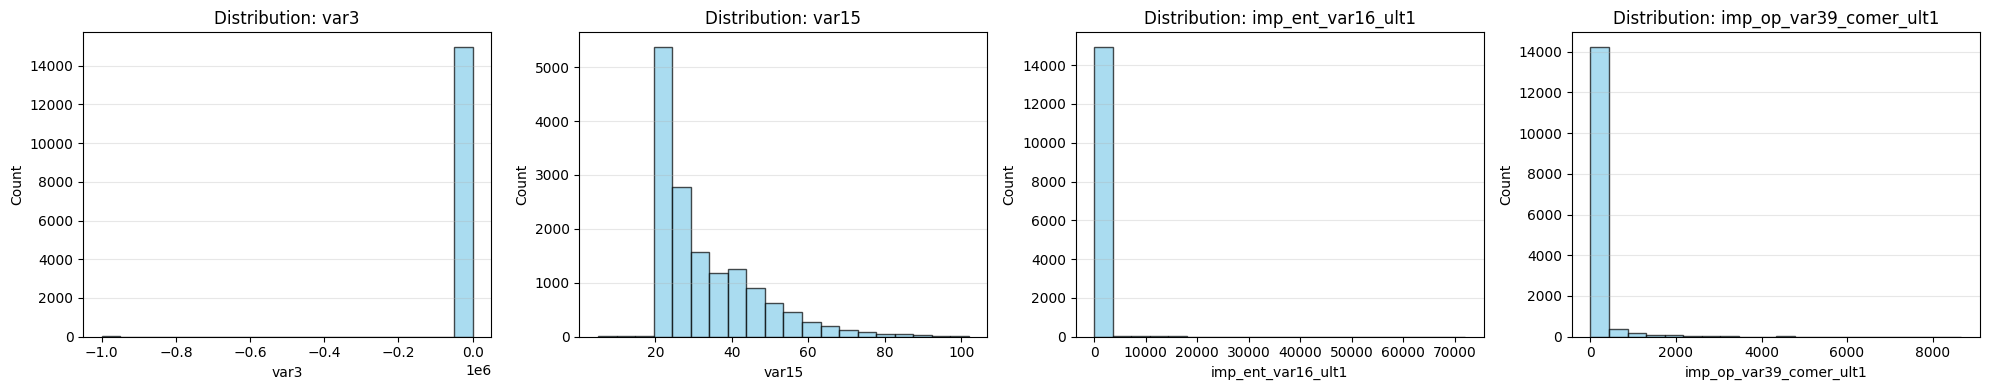

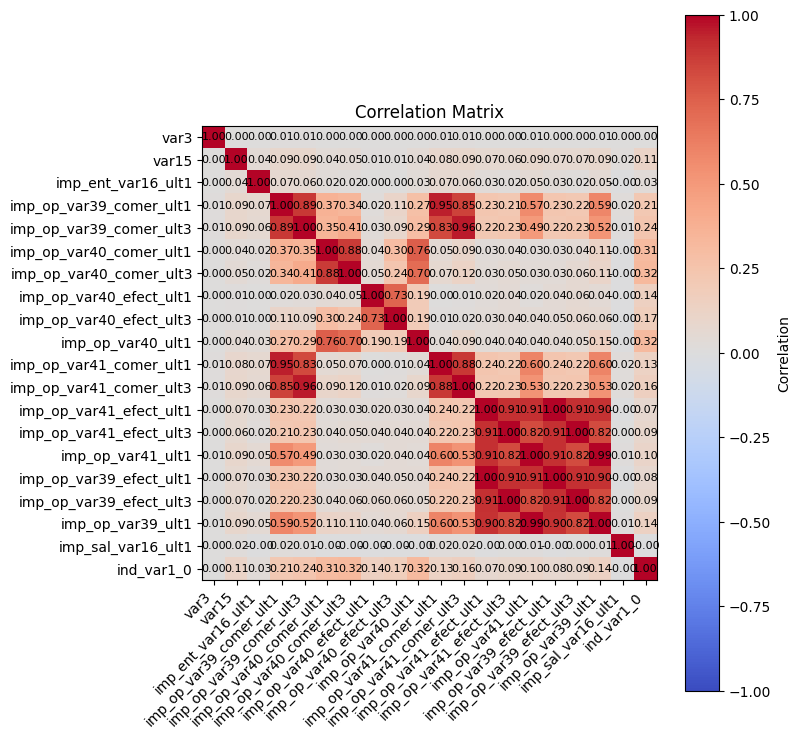

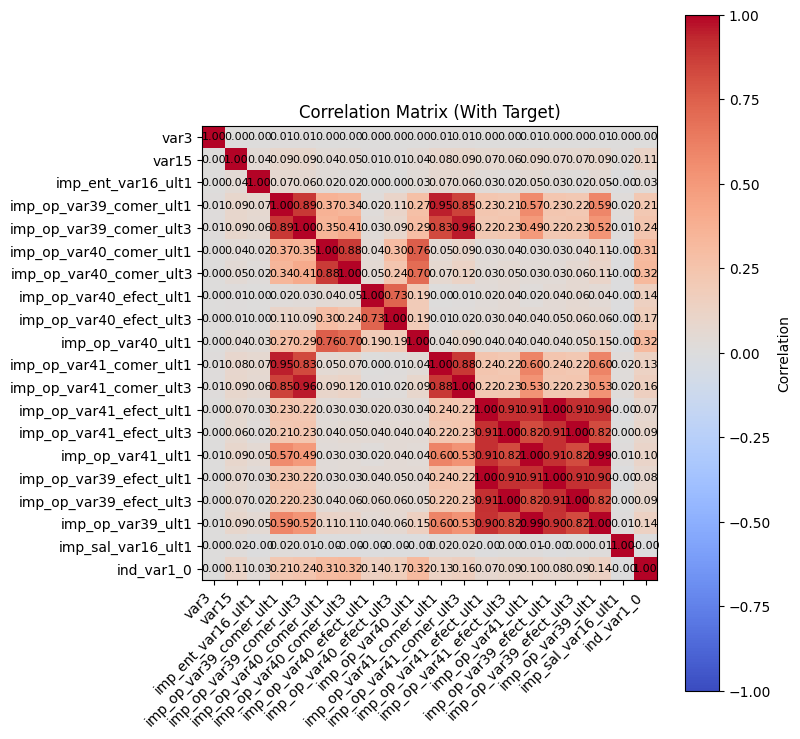

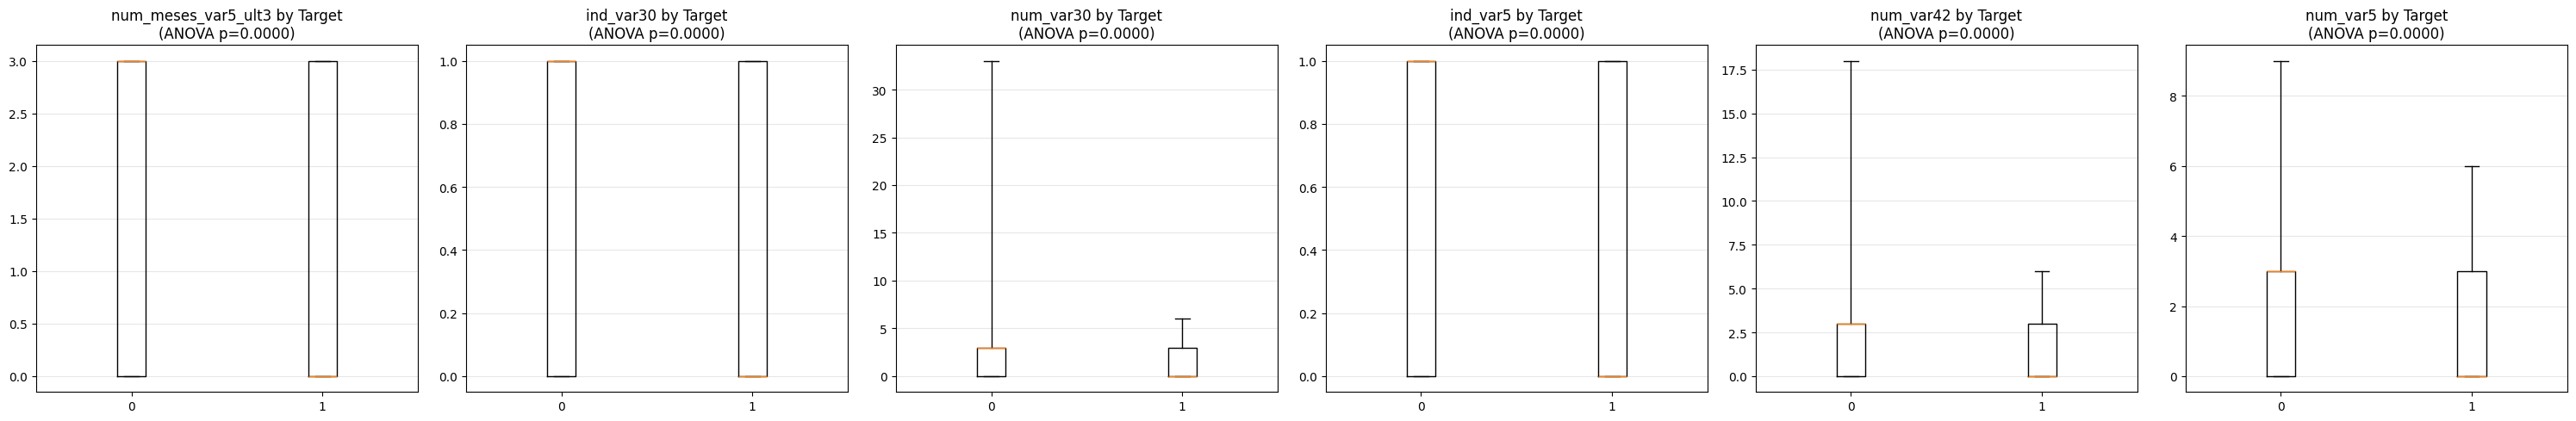

<Figure size 1000x1000 with 0 Axes>

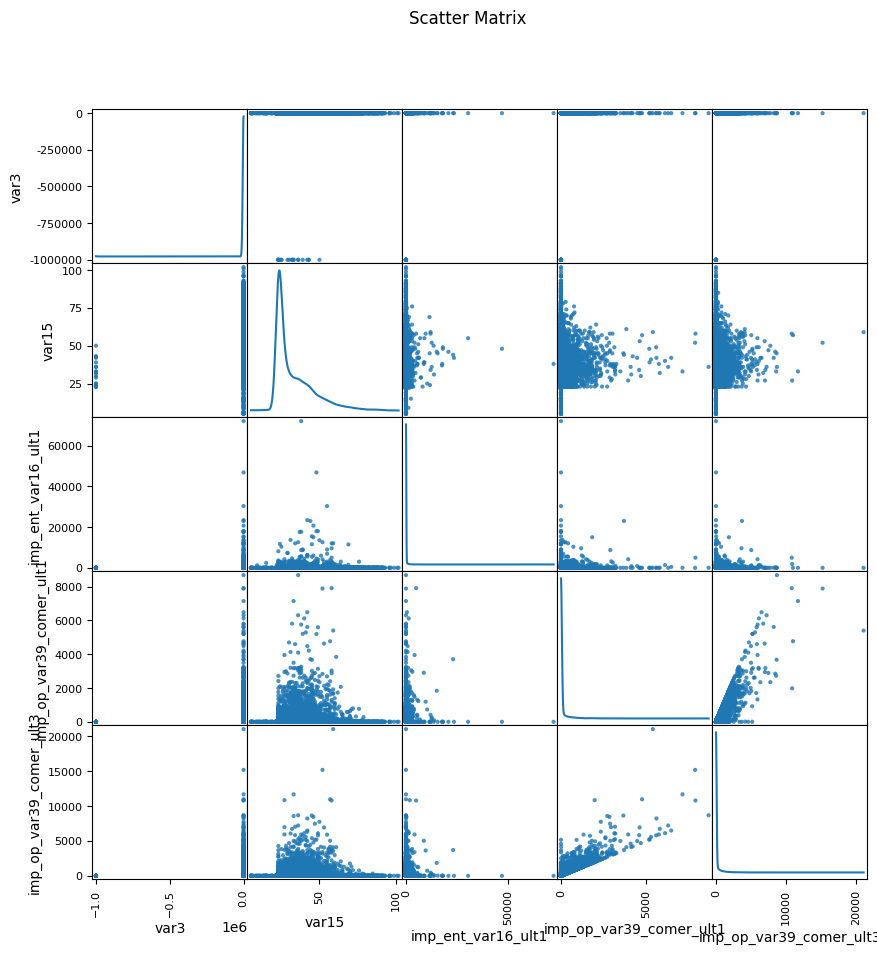

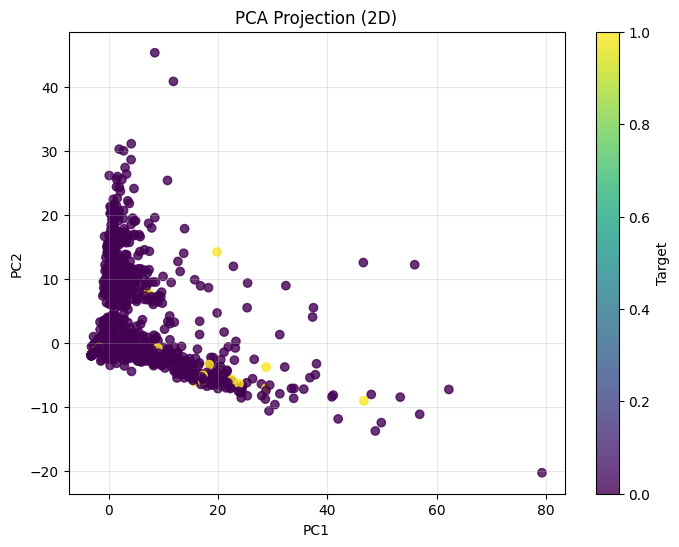

In [6]:
EDAVisualizer(profile, train.drop("ID")).plot()

## 2. Data-quality gates

Confirm no missing values (real for this dataset) and that `TARGET` is
binary, before doing anything else.

In [7]:
assert train.null_count().sum_horizontal().sum() == 0, "expected no nulls"
assert set(train["TARGET"].unique().to_list()) == {0, 1}, "TARGET must be binary"
print("Data-quality gates passed: no nulls, binary target.")

Data-quality gates passed: no nulls, binary target.


## 3. Split first, then check for drift

We take a quick stratified train/test split (kept in sync with the
`stratify=True, target_column="TARGET"` split used inside the pipeline
below) and run `DriftCalculator` train-vs-test as a stand-in for a
train-vs-production drift check — with iid stratified splits we *expect*
to see little to no drift, which is itself a useful sanity check that the
split didn't accidentally introduce skew.

In [8]:
# A plain stratified index split (numpy/sklearn only) purely to *illustrate*
# the drift check here; the real leakage-safe split used for modeling below
# happens inside the `SkyulfPipeline` config via the `TrainTestSplitter` node.
from sklearn.model_selection import train_test_split as _sk_split

frame_no_id = train.drop("ID")
train_idx, test_idx = _sk_split(
    np.arange(frame_no_id.height), test_size=0.2, random_state=42,
    stratify=frame_no_id["TARGET"].to_numpy(),
)
train_split = frame_no_id[train_idx]
test_split = frame_no_id[test_idx]
print(train_split.shape, test_split.shape)
print(f"train positive rate: {train_split['TARGET'].mean():.4%}  test positive rate: {test_split['TARGET'].mean():.4%}")

(12000, 370) (3000, 370)
train positive rate: 3.9583%  test positive rate: 3.9667%


In [9]:
drift_report = DriftCalculator(train_split, test_split).calculate_drift()
drifted = [c for c, d in drift_report.column_drifts.items() if d.drift_detected]
print(f"Columns checked: {len(drift_report.column_drifts)}  Drifted: {len(drifted)}")
print(drifted[:10])

Columns checked: 370  Drifted: 0
[]


## 4. Leakage-safe pipeline

`VarianceThreshold` drops constant columns, `CorrelationThreshold` collapses
near-duplicate correlated features, `StandardScaler` normalizes scale, and
`Oversampling` (SMOTE) balances the training split only — none of these
learn anything from the test split.

In [10]:
base_preprocessing = [
    {"name": "drop_constants", "transformer": "VarianceThreshold", "params": {"threshold": 0.0}},
    {"name": "drop_correlated", "transformer": "CorrelationThreshold", "params": {"threshold": 0.97}},
    {"name": "scale", "transformer": "StandardScaler", "params": {}},
]

logreg_config = {
    "preprocessing": [
        {"name": "split", "transformer": "TrainTestSplitter",
         "params": {"test_size": 0.2, "random_state": 42, "stratify": True, "target_column": "TARGET"}},
        *base_preprocessing,
        {"name": "balance", "transformer": "Oversampling",
         "params": {"method": "smote", "target_column": "TARGET", "sampling_strategy": "auto", "random_state": 42}},
    ],
    "modeling": {"type": "logistic_regression", "params": {"max_iter": 2000, "class_weight": "balanced"}},
}

logreg_pipeline = SkyulfPipeline(logreg_config)
logreg_metrics = logreg_pipeline.fit(train.drop("ID"), target_column="TARGET")

## 5. Tuned gradient boosting comparison

In [11]:
hgb_config = {
    "preprocessing": [
        {"name": "split", "transformer": "TrainTestSplitter",
         "params": {"test_size": 0.2, "random_state": 42, "stratify": True, "target_column": "TARGET"}},
        *base_preprocessing,
        {"name": "balance", "transformer": "Oversampling",
         "params": {"method": "smote", "target_column": "TARGET", "sampling_strategy": 0.3, "random_state": 42}},
    ],
    "modeling": {
        "type": "hyperparameter_tuner",
        "base_model": {"type": "hist_gradient_boosting_classifier"},
        "strategy": "random",
        "metric": "roc_auc",
        "n_trials": 12,
        "search_space": {
            "max_depth": [3, 5, 7, None],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_iter": [100, 200],
        },
        "cv_folds": 3,
        "random_state": 42,
    },
}

hgb_pipeline = SkyulfPipeline(hgb_config)
hgb_metrics = hgb_pipeline.fit(train.drop("ID"), target_column="TARGET")

## 6. Compare (ROC-AUC first, not accuracy)

In [12]:
def summarize(name, metrics):
    m = metrics["modeling"]
    report = m["splits"]["test"] if "splits" in m else m["test"]
    metrics_dict = report.metrics if hasattr(report, "metrics") else report
    auc = metrics_dict.get("roc_auc")
    precision = metrics_dict.get("precision")
    recall = metrics_dict.get("recall")
    acc = metrics_dict.get("accuracy")
    print(f"{name:20s} roc_auc={auc}  precision={precision}  recall={recall}  accuracy={acc}")


summarize("Logistic Regression (balanced)", logreg_metrics)
summarize("Tuned HistGradientBoosting", hgb_metrics)

Logistic Regression (balanced) roc_auc=0.7881658737774874  precision=0.10866752910737387  recall=0.7058823529411765  accuracy=0.7586666666666667
Tuned HistGradientBoosting roc_auc=0.8034441822546444  precision=0.20567375886524822  recall=0.24369747899159663  accuracy=0.9326666666666666


## Takeaways

- With ~96/4 class imbalance, **ROC-AUC and recall/precision matter far more
  than accuracy** — a model predicting "satisfied" for everyone would score
  ~96% accuracy while being useless.
- `VarianceThreshold` + `CorrelationThreshold` cut the 369-column feature
  space down substantially before modeling, which both speeds up training and
  reduces overfitting risk from redundant/constant columns.
- `Oversampling` (SMOTE) is applied **after** the split and fit only on the
  training fold, so the test split's class balance stays representative of
  reality — a common leakage mistake is balancing before splitting.